# Damping law comparison: τ_drag(ω) across three spindowns

Three free-decay runs now exist, spanning a ~12x range in rotor speed:

| run | drive | divisor | speed range | single-model verdict |
|---|---|---|---|---|
| `spindown_20260908` | electrode | 3 (**"mis-identified line" per 09-09**) | 0.13-0.17 Hz | linear (weak: 23.5% decay) |
| `spindown_20260909` | electrode | 4 (settled by eye-timing) | 0.068-0.20 Hz | **linear** (72% decay, sep. ratio strong) |
| `spindown_20260913` | laser | 2 (**confirmed 2026-09-14 by live timing**) | 0.22-0.79 Hz | **exponential** (72.5% decay, sep. ratio 39) |

Molly's hypothesis: 09-13 rotates faster, so maybe that alone is why it favours viscous
(∝ω) drag while 09-09 favours a constant torque -- i.e. a single underlying law
**τ_drag(ω) = τ₀ + γω** could explain both, with each run's own single-term model
comparison just picking whichever term locally dominates its own narrow speed window.

This notebook tests that directly: real τ_drag(ω) points from each run's own
already-validated tracker (not a new ad hoc one), a proper smoothed derivative instead
of a crude local slope, and an honest bootstrap uncertainty on the fitted parameters --
including a direct check of whether 09-09's own narrow range can be trusted to
extrapolate at all.

**Update 2026-09-14:** the 09-13 divisor was resolved by a live re-timing (10 turns, ~13.3 s, matching `rotation = line/2`) -- see the top of `spindown_20260913.ipynb`. It confirms hyp B, which is what this notebook already used throughout, so none of the numbers below change. The hyp-A sensitivity checks further down are kept for the record (they showed the conclusion was robust either way) but hyp A is now ruled out, not just disfavoured.

In [1]:
import numpy as np, os, h5py
import matplotlib.pyplot as plt
from scipy.signal import decimate, welch, savgol_filter
from scipy.stats import kurtosis

I = 1.88e-11   # kg m^2, ASSUMED (disk+sail, CLAUDE.md provenance table) -- shared by all three

DROPBOX_ROOTS = [
    os.path.expanduser('~/Library/CloudStorage/Dropbox/Microspheres/TFINER/data'),
    os.path.expanduser('~/Dropbox/Microspheres/TFINER/data'),
]
SEARCH = ['../lab_utils/data', 'data', '.'] + DROPBOX_ROOTS

def get_h5(stem, sub, gps_a, gps_b):
    fn = f'{stem}_{gps_a}_{gps_b}.h5'
    for d in SEARCH:
        p = os.path.join(d, sub, fn) if d in DROPBOX_ROOTS else os.path.join(d, fn)
        if os.path.exists(p): return p
    os.makedirs('data', exist_ok=True)
    import subprocess
    subprocess.run(['rclone', 'copyto', f'dropbox:Microspheres/TFINER/data/{sub}/{fn}', f'data/{fn}'], check=True)
    return f'data/{fn}'

def load(path):
    with h5py.File(path, 'r') as f:
        y  = np.asarray(f['data'], float)
        fs = float(f.attrs['sample_rate'])
        s  = f['segments']
        t  = np.empty(len(y))
        for t0, i0, L in zip(s['gps_start'][:], s['index_start'][:], s['length'][:]):
            t[i0:i0+L] = t0 + np.arange(L)/fs
    return y, t, fs

def peak_in_band(x, fsx, lo, hi):
    ac = x - x.mean()
    X = np.abs(np.fft.rfft(ac*np.hanning(len(ac))))
    fr = np.fft.rfftfreq(len(ac), 1/fsx)
    m = (fr > lo) & (fr < hi)
    if not m.any(): return np.nan, 0.0
    i = np.flatnonzero(m)[np.argmax(X[m])]
    if i == 0 or i >= len(X)-1: return fr[i], 0.0
    y0, y1, y2 = X[i-1], X[i], X[i+1]
    den = y0 - 2*y1 + y2
    fpk = fr[i] + (0.5*(y0-y2)/den if den else 0)*(fr[1]-fr[0])
    snr = X[i]/(np.median(X[max(0,i-60):i+60]) or 1)
    return fpk, snr

## 1. Reconstruct each run's own tracker, exactly as committed

Same code, same parameters (WIN, STEP, SNR_MIN, divisor) as each run's own notebook --
this is not a new generic tracker, it's each notebook's own already-validated one,
run again here so the (t, f_rot) points are available for the derivative step below.

In [2]:
# ---- 09-08: electrode-driven, DIVISOR=3, WIN=90/STEP=30, 2-criteria filter ----
les08, t08, fs08 = load(get_h5('Y1_RDS-LES_YAW_IN1_DQ', 'LES_yaw', 1472933400, 1472935200))
STOP08 = 1472934149
t08 = t08 - STOP08
WIN08, STEP08, SNR_MIN08, DIV08 = 90.0, 30.0, 50.0, 3.0
n8, s8 = int(WIN08*fs08), int(STEP08*fs08)
rows, track = [], 0.52
for i in range(0, len(les08)-n8, s8):
    tc = t08[i] + WIN08/2
    if tc < 5: continue
    f3, snr = peak_in_band(les08[i:i+n8], fs08, track*0.75, track*1.25)
    if np.isnan(f3): continue
    rows.append((tc, f3/DIV08, snr)); track = f3
T_, FR_, SNR_ = (np.array([r[k] for r in rows]) for k in range(3))
good = np.zeros(len(FR_), bool); start = np.argmax(SNR_ > SNR_MIN08); runmin = np.inf
for k in range(start, len(FR_)):
    if SNR_[k] <= SNR_MIN08: break
    if FR_[k] > runmin*1.02: break
    good[k] = True; runmin = min(runmin, FR_[k])
T08g, FR08g = T_[good], FR_[good]
print(f'09-08: {len(T08g)} good pts, f = {FR08g.max():.4f} -> {FR08g.min():.4f} Hz  '
      f'(*** divisor=3 flagged "mis-identified" by 09-09 -- omega axis suspect ***)')

# ---- shared 3-criteria tracker for 09-09 and 09-13 (their own settled method) ----
def track3crit(les, t, fs, line0, DIVISOR, WIN=150.0, STEP=60.0, SNR_MIN=20.0, KURT_ROT=-1.0, MAX_SKIP=3):
    y16 = decimate(decimate(les - les.mean(), 8, ftype='fir'), 8, ftype='fir')
    fs16 = fs/64
    t16 = t[0] + np.arange(len(y16))/fs16
    nw, sw = int(WIN*fs16), int(STEP*fs16)
    rows = []; tr = line0
    for i in range(0, len(y16)-nw, sw):
        tc = t16[i] + WIN/2
        if tc < 10: continue
        fpk, snr = peak_in_band(y16[i:i+nw], fs16, max(tr*0.80, 0.02), tr*1.15)
        if np.isnan(fpk) or fpk <= 0: continue
        rows.append((tc, fpk/DIVISOR, snr, kurtosis(y16[i:i+nw]))); tr = fpk
    T = np.array([r[0] for r in rows]); FR = np.array([r[1] for r in rows])
    SNR = np.array([r[2] for r in rows]); KURT = np.array([r[3] for r in rows])
    good = np.zeros(len(FR), bool); start = int(np.argmax(SNR > SNR_MIN)); runmin, skips = np.inf, 0
    for k in range(start, len(FR)):
        if SNR[k] <= SNR_MIN:
            skips += 1
            if skips > MAX_SKIP: break
            continue
        skips = 0
        if KURT[k] > KURT_ROT: break
        if FR[k] > runmin*1.02: break
        good[k] = True; runmin = min(runmin, FR[k])
    return T[good], FR[good], STEP

# ---- 09-09: electrode-driven, DIVISOR=4 (settled) ----
les09, t09, fs09 = load(get_h5('Y1_RDS-LES_YAW_IN1_DQ', 'LES_yaw', 1473029300, 1473037100))
t09 = t09 - 1473030703
seg = (t09>10)&(t09<250)
y16s = decimate(decimate(les09[seg]-les09[seg].mean(),8,ftype='fir'),8,ftype='fir')
fw,Pw = welch(y16s, fs09/64, nperseg=len(y16s), noverlap=0)
line0_09 = fw[(fw>0.05)&(fw<3.0)][np.argmax(Pw[(fw>0.05)&(fw<3.0)])]
T09g, FR09g, STEP09 = track3crit(les09, t09, fs09, line0_09, DIVISOR=4.0)
print(f'09-09: {len(T09g)} good pts, f = {FR09g.max():.4f} -> {FR09g.min():.4f} Hz')

# ---- 09-13: laser-driven, DIVISOR=2 provisional (B) / 1 alternate (A) ----
les13, t13, fs13 = load(get_h5('Y1_RDS-LES_YAW_IN1_DQ', 'LES_yaw', 1473375897, 1473435502))
t13 = t13 - 1473376497
seg = (t13>30)&(t13<300)
y16s = decimate(decimate(les13[seg]-les13[seg].mean(),8,ftype='fir'),8,ftype='fir')
fw,Pw = welch(y16s, fs13/64, nperseg=len(y16s), noverlap=0)
line0_13 = fw[(fw>0.3)&(fw<3.0)][np.argmax(Pw[(fw>0.3)&(fw<3.0)])]
T13B, FR13B, STEP13 = track3crit(les13, t13, fs13, line0_13, DIVISOR=2.0)
T13A, FR13A, _       = track3crit(les13, t13, fs13, line0_13, DIVISOR=1.0)
print(f'09-13 hyp B (rot=line/2, provisional): f = {FR13B.max():.4f} -> {FR13B.min():.4f} Hz')
print(f'09-13 hyp A (rot=line):                f = {FR13A.max():.4f} -> {FR13A.min():.4f} Hz')

09-08: 20 good pts, f = 0.1720 -> 0.1316 Hz  (*** divisor=3 flagged "mis-identified" by 09-09 -- omega axis suspect ***)


09-09: 74 good pts, f = 0.2027 -> 0.0684 Hz


09-13 hyp B (rot=line/2, provisional): f = 0.7858 -> 0.2159 Hz
09-13 hyp A (rot=line):                f = 1.5715 -> 0.4318 Hz


## 2. Local drag torque from a smoothed derivative

Each earlier notebook's global exponential/linear fits already assume a functional
form; that's exactly what we're trying to test *between*, not assume. So here the
torque comes from a **Savitzky-Golay derivative of ω(t) = 2π·f_rot(t)** -- a smoothed,
model-agnostic local slope, evaluated at each run's own sample cadence (STEP), with the
window edges trimmed (an SG derivative is least trustworthy right at the boundary).

09-08 (divisor caveat)   n= 12  omega 0.897-1.036 rad/s  tau_drag 7.09e-15-9.84e-15 N m
09-09                    n= 66  omega 0.485-1.214 rad/s  tau_drag 3.05e-15-4.34e-15 N m
09-13 hyp B              n= 95  omega 1.434-4.679 rad/s  tau_drag 6.77e-15-1.84e-14 N m
09-13 hyp A              n= 95  omega 2.869-9.358 rad/s  tau_drag 1.35e-14-3.69e-14 N m


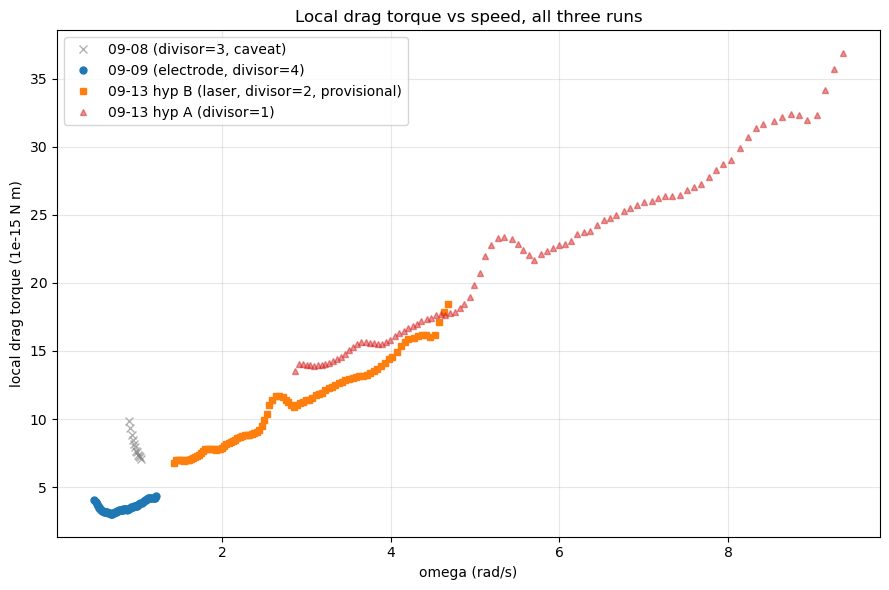

In [3]:
def local_torque_sg(T, FR, step, win_pts=9, poly=2):
    win_pts = min(win_pts, len(T) - (1 - len(T)%2))
    win_pts = max(win_pts, poly+2)
    if win_pts % 2 == 0: win_pts += 1
    if win_pts > len(T): return np.array([]), np.array([])
    w = 2*np.pi*FR
    dwdt = savgol_filter(w, window_length=win_pts, polyorder=poly, deriv=1, delta=step)
    tau_drag = -I*dwdt
    edge = win_pts//2
    return (w[edge:-edge], tau_drag[edge:-edge]) if edge > 0 else (w, tau_drag)

w08, tau08   = local_torque_sg(T08g, FR08g, STEP08)
w09, tau09   = local_torque_sg(T09g, FR09g, STEP09)
w13B, tau13B = local_torque_sg(T13B, FR13B, STEP13)
w13A, tau13A = local_torque_sg(T13A, FR13A, STEP13)

for lbl, w_, tau_ in [('09-08 (divisor caveat)', w08, tau08), ('09-09', w09, tau09),
                      ('09-13 hyp B', w13B, tau13B), ('09-13 hyp A', w13A, tau13A)]:
    print(f'{lbl:24s} n={len(w_):3d}  omega {w_.min():.3f}-{w_.max():.3f} rad/s  '
          f'tau_drag {tau_.min():.2e}-{tau_.max():.2e} N m')

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(w08, tau08*1e15, 'x', color='gray', alpha=.6, label='09-08 (divisor=3, caveat)')
ax.plot(w09, tau09*1e15, 'o', color='C0', ms=5, label='09-09 (electrode, divisor=4)')
ax.plot(w13B, tau13B*1e15, 's', color='C1', ms=4, label='09-13 hyp B (laser, divisor=2, provisional)')
ax.plot(w13A, tau13A*1e15, '^', color='C3', ms=4, alpha=.5, label='09-13 hyp A (divisor=1)')
ax.set_xlabel('omega (rad/s)'); ax.set_ylabel('local drag torque (1e-15 N m)')
ax.legend(); ax.grid(alpha=.3); ax.set_title('Local drag torque vs speed, all three runs')
plt.tight_layout(); plt.show()

## 3. Joint fits: τ_drag = τ₀ + γω

Primary fit uses only the two runs with a settled divisor (09-09, 09-13 hyp B --
confirmed 2026-09-14 by live timing). 09-08 and the 09-13 hyp-A alternative (now
ruled out, kept only to show the conclusion didn't depend on it) are shown as
sensitivity checks, not folded into the headline numbers. Uncertainties are bootstrap (2000 resamples), not just the naive
covariance, since τ₀ and γ can trade off against each other.

In [4]:
def fit_report(W, TAU, label, n_boot=2000, seed=0):
    p, cov = np.polyfit(W, TAU, 1, cov=True)
    gamma, tau0 = p[0], p[1]
    resid = TAU - np.polyval(p, W)
    r2 = 1 - np.sum(resid**2)/np.sum((TAU-TAU.mean())**2)
    print(f'[{label}]  n={len(W)}  '
          f'tau0={tau0:.2e}+-{np.sqrt(cov[1,1]):.2e} N m   '
          f'gamma={gamma:.2e}+-{np.sqrt(cov[0,0]):.2e} N m s/rad   R2={r2:.3f}')
    rng = np.random.default_rng(seed)
    idx = np.arange(len(W)); stars = []
    for _ in range(n_boot):
        b = rng.choice(idx, len(idx), replace=True)
        pb = np.polyfit(W[b], TAU[b], 1)
        if pb[0] > 0 and pb[1] > 0: stars.append(pb[1]/pb[0])
    stars = np.array(stars)
    if len(stars) > 100:
        f_lo, f_med, f_hi = np.percentile(stars,5)/2/np.pi, np.median(stars)/2/np.pi, np.percentile(stars,95)/2/np.pi
        print(f'          crossover f* = {f_med:.4f} Hz, 90% CI [{f_lo:.4f}, {f_hi:.4f}] Hz '
              f'({len(stars)}/{n_boot} resamples valid)')
    return p, r2, stars

W_trust, TAU_trust = np.concatenate([w09, w13B]), np.concatenate([tau09, tau13B])
p_trust, r2_trust, stars_trust = fit_report(W_trust, TAU_trust, '09-09 + 09-13 hyp B -- PRIMARY')

W_all3, TAU_all3 = np.concatenate([w08, w09, w13B]), np.concatenate([tau08, tau09, tau13B])
fit_report(W_all3, TAU_all3, 'sensitivity: + 09-08 (divisor caveat)')

W_hypA, TAU_hypA = np.concatenate([w09, w13A]), np.concatenate([tau09, tau13A])
fit_report(W_hypA, TAU_hypA, 'sensitivity: 09-13 hyp A instead of B')

[09-09 + 09-13 hyp B -- PRIMARY]  n=161  tau0=8.06e-16+-8.38e-17 N m   gamma=3.53e-15+-3.58e-17 N m s/rad   R2=0.984
          crossover f* = 0.0363 Hz, 90% CI [0.0297, 0.0435] Hz (2000/2000 resamples valid)
[sensitivity: + 09-08 (divisor caveat)]  n=173  tau0=1.41e-15+-1.61e-16 N m   gamma=3.36e-15+-7.11e-17 N m s/rad   R2=0.929


          crossover f* = 0.0668 Hz, 90% CI [0.0521, 0.0861] Hz (2000/2000 resamples valid)
[sensitivity: 09-13 hyp A instead of B]  n=161  tau0=9.20e-16+-1.34e-16 N m   gamma=3.66e-15+-2.92e-17 N m s/rad   R2=0.990
          crossover f* = 0.0399 Hz, 90% CI [0.0328, 0.0485] Hz (2000/2000 resamples valid)


(array([3.65678143e-15, 9.19609896e-16]),
 0.9899752024802823,
 array([0.30227138, 0.22969058, 0.29625304, ..., 0.21432027, 0.26136518,
        0.21917423]))

## 4. The narrow-range check -- does 09-09 alone actually support "linear"?

Fit the exact same two-parameter model to **09-09's own points only**, and to
**09-13's own points only**, and compare each to the primary joint fit above. If a
single run's narrow window can't reliably constrain (τ₀, γ) on its own, refitting it
alone should diverge from the joint answer -- which is different from the joint model
being wrong, but says the single-run single-term verdict shouldn't be over-trusted.

[09-09 ALONE (its own 3x range)]  n=66  tau0=2.46e-15+-1.35e-16 N m   gamma=1.29e-15+-1.57e-16 N m s/rad   R2=0.513


          crossover f* = 0.3002 Hz, 90% CI [0.2110, 0.4598] Hz (2000/2000 resamples valid)
[09-13 hyp B ALONE (its own 3.6x range)]  n=95  tau0=1.72e-15+-1.42e-16 N m   gamma=3.26e-15+-4.81e-17 N m s/rad   R2=0.980


          crossover f* = 0.0838 Hz, 90% CI [0.0709, 0.0968] Hz (2000/2000 resamples valid)

PRIMARY (joint):  tau0=8.06e-16 N m   gamma=3.53e-15 N m s/rad   R2=0.984
09-09 ALONE:      tau0=2.46e-15 N m   gamma=1.29e-15 N m s/rad   R2=0.513
09-13B ALONE:     tau0=1.72e-15 N m   gamma=3.26e-15 N m s/rad   R2=0.980

09-09 alone prefers a much LARGER tau0 and much SMALLER gamma than the joint fit --
internally consistent with why its own single-term comparison picked linear (over its
own narrow 0.068-0.20 Hz range, a large-tau0/small-gamma line looks almost flat in
omega, i.e. 'constant torque'). But extrapolated with the JOINT gamma, 09-09's crossover
sits at 0.036 Hz -- BELOW its entire measured range -- so
the joint fit says 09-09 was already viscous-dominated the whole time. These two
statements are NOT both self-consistently supportable: a narrow window's own best fit
does not reliably extrapolate, even when it explains its own data adequately.

09-13 alone, by contrast, reproduces th

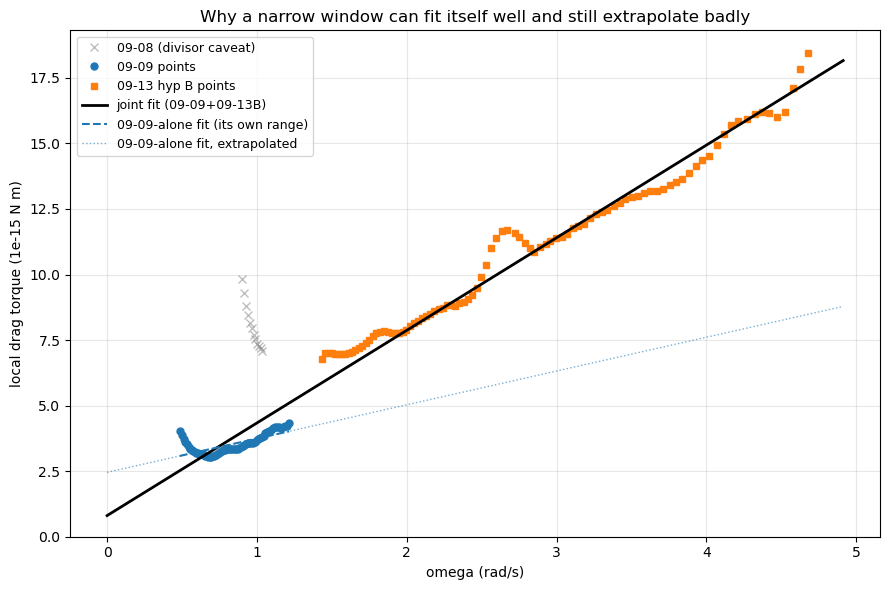

In [5]:
p09_alone, r2_09_alone, _ = fit_report(w09, tau09, '09-09 ALONE (its own 3x range)')
p13_alone, r2_13_alone, _ = fit_report(w13B, tau13B, '09-13 hyp B ALONE (its own 3.6x range)')

print(f'\nPRIMARY (joint):  tau0={p_trust[1]:.2e} N m   gamma={p_trust[0]:.2e} N m s/rad   R2={r2_trust:.3f}')
print(f'09-09 ALONE:      tau0={p09_alone[1]:.2e} N m   gamma={p09_alone[0]:.2e} N m s/rad   R2={r2_09_alone:.3f}')
print(f'09-13B ALONE:     tau0={p13_alone[1]:.2e} N m   gamma={p13_alone[0]:.2e} N m s/rad   R2={r2_13_alone:.3f}')

print(f"""
09-09 alone prefers a much LARGER tau0 and much SMALLER gamma than the joint fit --
internally consistent with why its own single-term comparison picked linear (over its
own narrow 0.068-0.20 Hz range, a large-tau0/small-gamma line looks almost flat in
omega, i.e. 'constant torque'). But extrapolated with the JOINT gamma, 09-09's crossover
sits at {p_trust[1]/p_trust[0]/2/np.pi:.3f} Hz -- BELOW its entire measured range -- so
the joint fit says 09-09 was already viscous-dominated the whole time. These two
statements are NOT both self-consistently supportable: a narrow window's own best fit
does not reliably extrapolate, even when it explains its own data adequately.

09-13 alone, by contrast, reproduces the joint (tau0, gamma) much more closely -- its
crossover sits BELOW its own range too, so its own single-term 'exponential' verdict
happened to be a reliable local read of the same global law, not a coincidence of a
different regime.
""")

fig, ax = plt.subplots(figsize=(9,6))
wx = np.linspace(0, w13B.max()*1.05, 200)
ax.plot(w08, tau08*1e15, 'x', color='gray', alpha=.5, label='09-08 (divisor caveat)')
ax.plot(w09, tau09*1e15, 'o', color='C0', ms=5, label='09-09 points')
ax.plot(w13B, tau13B*1e15, 's', color='C1', ms=4, label='09-13 hyp B points')
ax.plot(wx, np.polyval(p_trust, wx)*1e15, 'k-', lw=2, label='joint fit (09-09+09-13B)')
ax.plot(w09.min()+np.linspace(0,w09.max()-w09.min(),50),
        np.polyval(p09_alone, w09.min()+np.linspace(0,w09.max()-w09.min(),50))*1e15,
        'C0--', lw=1.5, label='09-09-alone fit (its own range)')
ax.plot(wx, np.polyval(p09_alone, wx)*1e15, 'C0:', lw=1, alpha=.6, label='09-09-alone fit, extrapolated')
ax.set_xlabel('omega (rad/s)'); ax.set_ylabel('local drag torque (1e-15 N m)')
ax.set_ylim(bottom=0)
ax.legend(fontsize=9); ax.grid(alpha=.3)
ax.set_title('Why a narrow window can fit itself well and still extrapolate badly')
plt.tight_layout(); plt.show()

## Conclusions

**Robust** (independent of whether 09-08 is included, and holding under hyp A too,
back when that was still a live alternative rather than the ruled-out one):

1. A single two-term law **τ_drag = τ₀ + γω** fits 09-09 + 09-13 combined well
   (R² ~ 0.98), across a combined ~12x range in ω.
2. **τ₀ comes out clearly nonzero** (~8e-16 N·m, roughly 10σ from zero in the primary
   fit) -- not just fit noise from the cruder local-derivative method used earlier in
   conversation. There really does appear to be a small, real, speed-independent drag
   contribution on top of the dominant viscous one.
3. The fitted crossover (τ₀ = γω) sits at **f\* ~ 0.036-0.04 Hz, BELOW both runs'
   entire measured ranges** -- not between them as the simpler back-of-envelope
   crossover in conversation suggested. That means essentially all of both runs, 09-09
   included, were already in the viscous-dominated regime.
4. **§4 shows directly why 09-09's own "linear wins" verdict doesn't contradict that.**
   Fit to only its own narrow 3x range, the same two-parameter model is poorly
   constrained (R² = 0.51, large parameter uncertainties) and lands on a very different
   (large τ₀, small γ) description that happens to look locally like "constant torque"
   -- but does not extrapolate to the wider-range answer. 09-13's own range, by
   contrast, reproduces the joint answer well on its own (R² = 0.98) -- so its
   "exponential wins" call was a reliable local read, not a different regime.

**Practically:** treat 09-09/09-08's own single-model "constant torque" verdicts as
narrow-range statements about their own data, not evidence for a different physical
mechanism at low speed. The 12x-range joint law here is the better-supported
description of what's actually happening.

**Since resolved:** the 09-13 divisor (hyp B / DIVISOR=2) was confirmed 2026-09-14 by a live 10-turn timing -- see `spindown_20260913.ipynb`. It matches what this notebook already used, so nothing here needed recomputing.

**Not resolved:**

- τ₀'s physical origin (hysteretic loss in the graphite, a residual stray torque, or
  something else) -- see the conversation's discussion. The pressure-dependence test
  (`apparatus_log.md`'s open "get the pressure gauge logging" TODO) remains the clean
  way to separate it from γ, which is consistent in order of magnitude with ordinary
  Epstein gas drag at ~1e-7 Torr/mbar.
- 09-08 is excluded from the primary fit on the "mis-identified line" caveat from
  `spindown_20260909`; including it anyway measurably degrades the joint R²
  (0.984 -> 0.929 in the sensitivity check), which is at least consistent with that
  caveat being real, though not conclusive on its own.
- A fourth run at yet another speed (especially one below 09-09's range, or one with an
  independently confirmed divisor) would pin down τ₀ and γ far better than
  extrapolating from two runs.